# Импорт библиотек

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
from pathlib import Path
from ensemble_boxes import weighted_boxes_fusion


import os
from scripts.preprocess.utils import process_image

from tqdm import tqdm

import matplotlib.image as mpimg

import seaborn as sns
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Пути

In [ ]:
TRAIN_RAW_CSV_PATH = Path('data/raw/train.csv')
TRAIN_DCM_PATH = Path(r'data/raw/train')

CNT_IMAGES = 5

TEST_PNG_PATH = Path('data/test_process')

TRAIN_PROCESSED_CSV_PATH = Path('data/processed/train_processed.csv')

TRAIN_PROCESSED_SPLIT_CSV_PATH = Path('data/processed/train_split.csv')
VAL_SPLIT_CSV_PATH = Path('data/processed/val_split.csv')
IMAGE_DIR = Path('data/processed/train')

TRAIN_PROCESSED_WBF_PATH = Path('data/processed/train_wbf.csv')

TRAIN_BALANCED_CSV_PATH = Path('data/processed/train_balanced.csv')

CSV_VAL_PATH = Path(r'E:\diploma\Project\data\processed\val_split.csv')
IMAGE_DIR = Path(r'E:\diploma\Project\data\processed\train')

NEW_CSV_TRAIN_PATH = Path(r'E:\diploma\Project\data\processed\train_split_new.csv')
NEW_CSV_VAL_PATH = Path(r'E:\diploma\Project\data\processed\val_split_new.csv')

# Создане PNG

Необходимо сравнить качество изображений и bbox-ов до и после предобработки. Поскольку фото сжимаются, необходимо создать новые датасеты test и train

In [5]:
df = pd.read_csv(TRAIN_RAW_CSV_PATH)
df

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
67909,936fd5cff1c058d39817a08f58b72cae,No finding,14,R1,NaN,NaN,NaN,NaN
67910,ca7e72954550eeb610fe22bf0244b7fa,No finding,14,R1,NaN,NaN,NaN,NaN
67911,aa17d5312a0fb4a2939436abca7f9579,No finding,14,R8,NaN,NaN,NaN,NaN
67912,4b56bc6d22b192f075f13231419dfcc8,Cardiomegaly,3,R8,771.0,979.0,1680.0,1311.0


In [56]:
sub_df = df.loc[df['class_name'] != 'No finding'].iloc[:CNT_IMAGES]
sub_df

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,wbf_score
4,00150343289f317a0ad5629d5b7d9ef9,Aortic enlargement,0,wbf_merged,467.187347,193.715103,681.044495,353.634857,1.0000
5,00150343289f317a0ad5629d5b7d9ef9,Cardiomegaly,3,wbf_merged,331.735446,430.282772,775.806733,546.674059,0.3333
6,00150343289f317a0ad5629d5b7d9ef9,Lung Opacity,7,wbf_merged,760.801584,450.560000,908.014257,544.240792,0.3333
7,00150343289f317a0ad5629d5b7d9ef9,Lung Opacity,7,wbf_merged,783.512079,455.020990,893.414653,502.469703,0.3333
8,00150343289f317a0ad5629d5b7d9ef9,Other lesion,9,wbf_merged,457.859802,125.718812,546.268515,345.929505,0.3333


In [57]:
file_names = sub_df['image_id'].to_list()
file_names

['00150343289f317a0ad5629d5b7d9ef9',
 '00150343289f317a0ad5629d5b7d9ef9',
 '00150343289f317a0ad5629d5b7d9ef9',
 '00150343289f317a0ad5629d5b7d9ef9',
 '00150343289f317a0ad5629d5b7d9ef9']

Исходные изображения

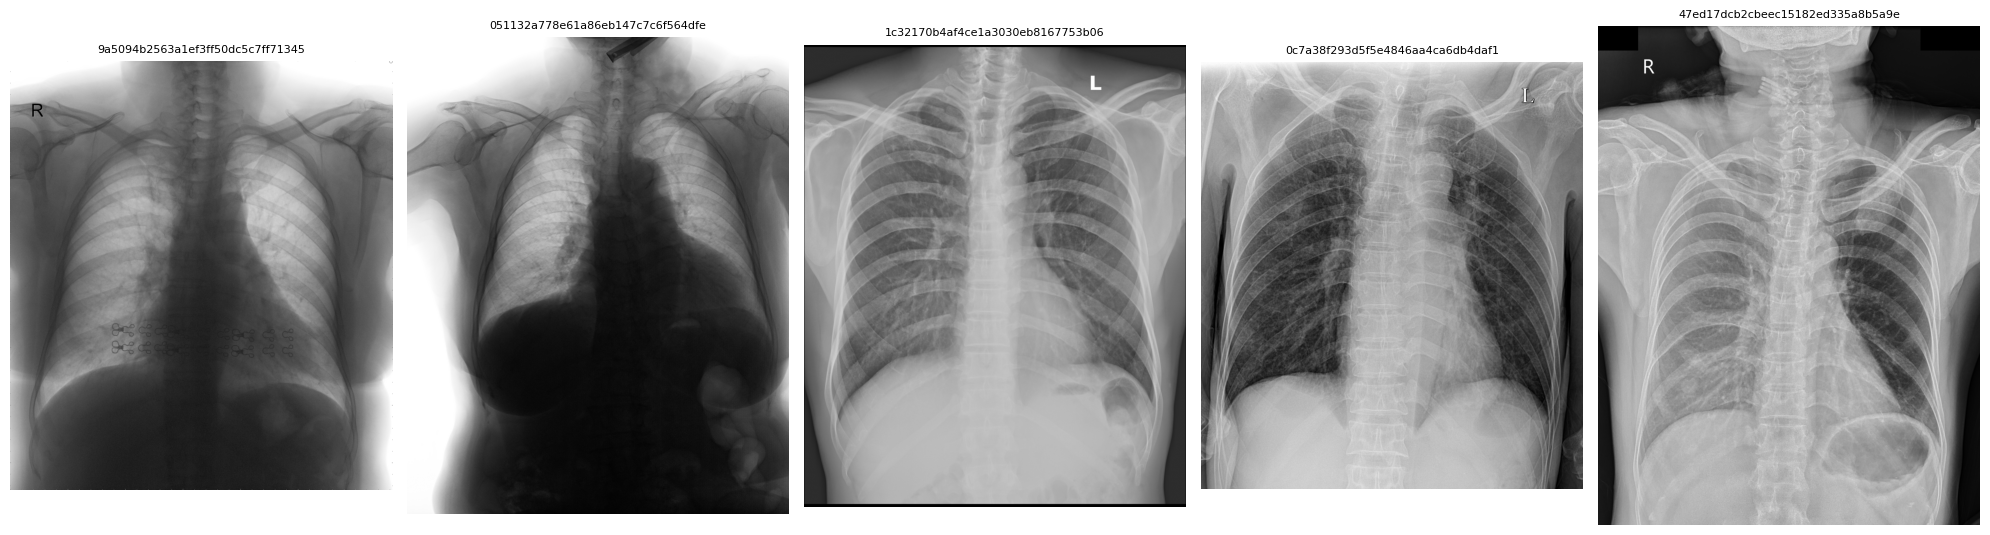

In [17]:
rows, cols = 1, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()

for i, fname in enumerate(file_names):
    file = pydicom.dcmread(fr'{TRAIN_DCM_PATH}\{fname}.dicom')
    img = file.pixel_array

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(fname, fontsize=8)
    axes[i].axis('off')

    # boxes = sub_df.loc[sub_df['image_id'] == fname, ['x_min', 'y_min', 'x_max', 'y_max']]
    # for _, row in boxes.iterrows():
    #     x_min, y_min, x_max, y_max = row.astype(float)
        
    #     width = x_max - x_min
    #     height = y_max - y_min
        
    #     rect = patches.Rectangle((x_min, y_min), width, height, 
    #                             linewidth=2, edgecolor='red', facecolor='none')
    #     axes[i].add_patch(rect)
    

plt.tight_layout()
plt.show()

Обработаем эти 5 файлов

In [58]:
for fname in file_names:
    process_image(TRAIN_DCM_PATH / f'{fname}.dicom', TEST_PNG_PATH / f'{fname}.png')

Напишем функцию для обработки bbox-ов

In [19]:
def process_bounding_box(origin_coords: list[float], origin_size: list[int], new_size: list[int]):
    width_old, height_old = origin_size
    side_new = new_size
    x_min, y_min, x_max, y_max = origin_coords

    side_old = max(width_old, height_old)
    offset_x = (side_old - width_old) // 2
    offset_y = (side_old - height_old) // 2

    scale = side_new / side_old

    x_min_new = (x_min + offset_x) * scale
    y_min_new = (y_min + offset_y) * scale
    x_max_new = (x_max + offset_x) * scale
    y_max_new = (y_max + offset_y) * scale

    return x_min_new, y_min_new, x_max_new, y_max_new

Выведем обработанные изображения

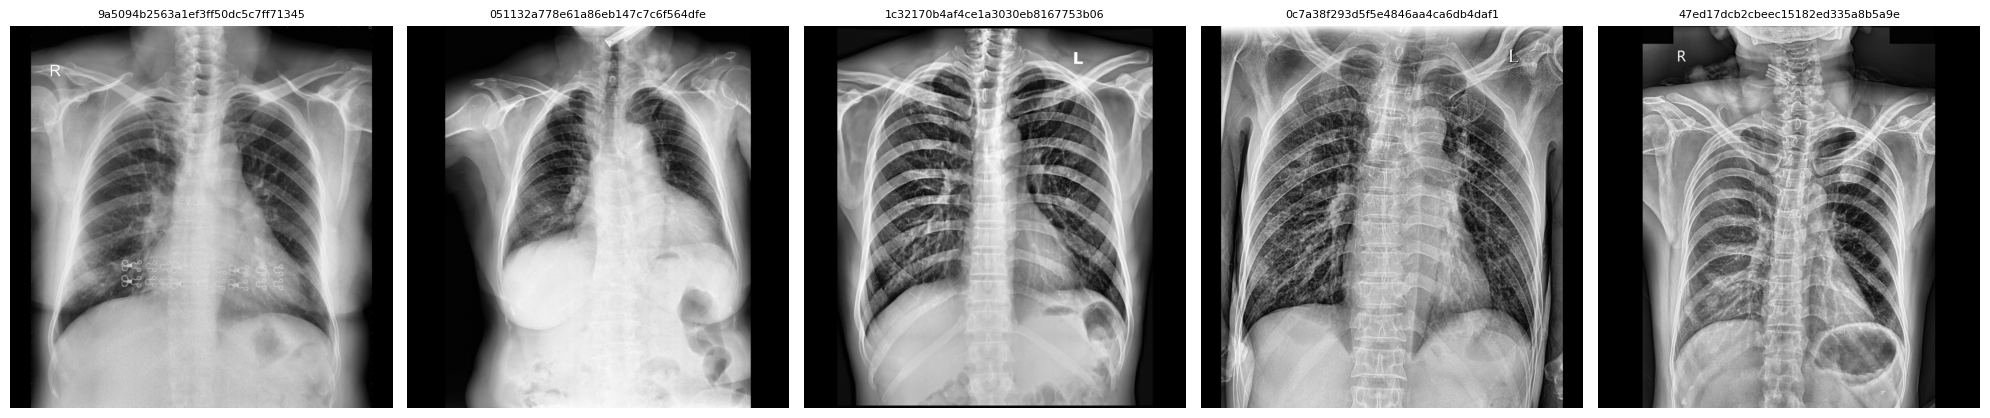

In [25]:
rows, cols = 1, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()

for i, fname in enumerate(file_names):
    file = pydicom.dcmread(TRAIN_DCM_PATH / f'{fname}.dicom')
    img = mpimg.imread(TEST_PNG_PATH / f'{fname}.png')

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(fname, fontsize=8)
    axes[i].axis('off')

    boxes = sub_df.loc[sub_df['image_id'] == fname, ['x_min', 'y_min', 'x_max', 'y_max']]
    # for _, row in boxes.iterrows():
    #     x_min, y_min, x_max, y_max = process_bounding_box(row.astype(float), [file.Columns, file.Rows], 1024)
        
    #     width = x_max - x_min
    #     height = y_max - y_min
        
    #     rect = patches.Rectangle((x_min, y_min), width, height, 
    #                             linewidth=2, edgecolor='red', facecolor='none')
    #     axes[i].add_patch(rect)
    

plt.tight_layout()
plt.show()

## Сравнение

Выведем фото с bbox-ми до и после обработки и сравним

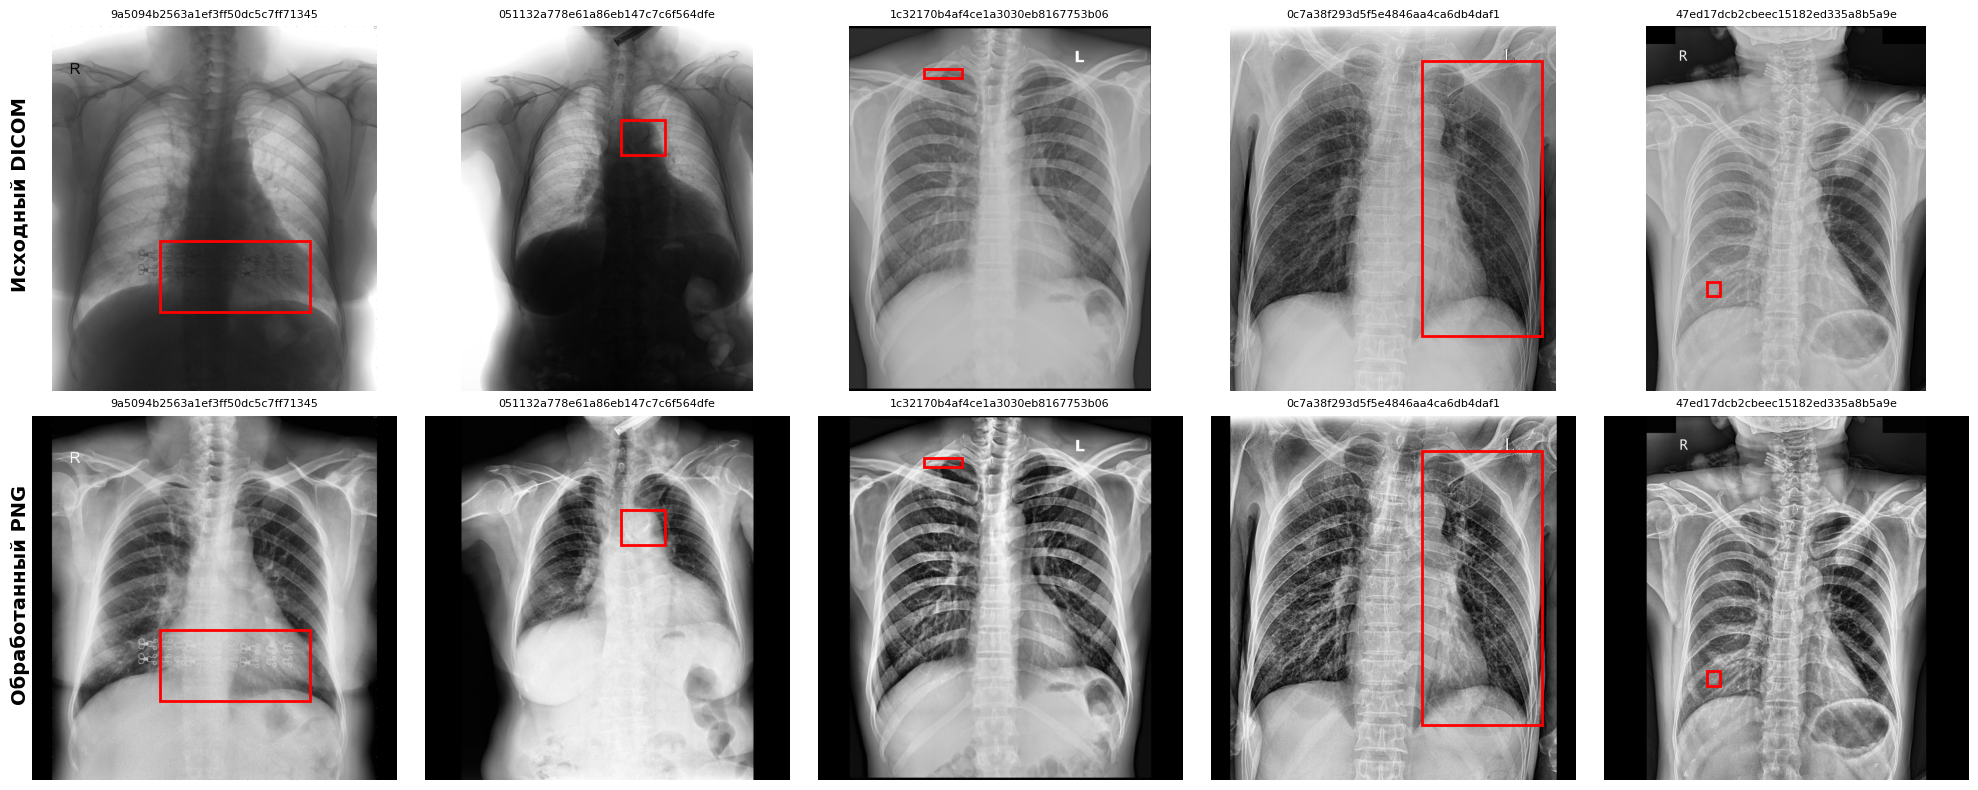

In [26]:
rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()

for i, fname in enumerate(file_names):
    file = pydicom.dcmread(TRAIN_DCM_PATH / f'{fname}.dicom')
    img = file.pixel_array

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(fname, fontsize=8)
    axes[i].axis('off')

    img = mpimg.imread(TEST_PNG_PATH / f'{fname}.png')
    axes[i + CNT_IMAGES].imshow(img, cmap='gray')
    axes[i + CNT_IMAGES].set_title(fname, fontsize=8)
    axes[i + CNT_IMAGES].axis('off')

    boxes = sub_df.loc[sub_df['image_id'] == fname, ['x_min', 'y_min', 'x_max', 'y_max']]
    for _, row in boxes.iterrows():
        x_min_origin, y_min_origin, x_max_origin, y_max_origin = row.astype(float)
        
        width_origin = x_max_origin - x_min_origin
        height_origin = y_max_origin - y_min_origin
        
        rect_origin = patches.Rectangle((x_min_origin, y_min_origin), width_origin, height_origin, 
                                linewidth=2, edgecolor='red', facecolor='none')
        axes[i].add_patch(rect_origin)


        x_min_new, y_min_new, x_max_new, y_max_new = process_bounding_box(row.astype(float), [file.Columns, file.Rows], 1024)
        
        width_new = x_max_new - x_min_new
        height_new = y_max_new - y_min_new
        
        rect_new = patches.Rectangle((x_min_new, y_min_new), width_new, height_new, 
                                linewidth=2, edgecolor='red', facecolor='none')
        axes[i + CNT_IMAGES].add_patch(rect_new)

fig.text(0.01, 0.75, 'Исходный DICOM', rotation=90, 
         va='center', fontsize=14, fontweight='bold')

fig.text(0.01, 0.25, 'Обработанный PNG', rotation=90, 
         va='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0.01, 0, 1, 1])

plt.show()

# Создание датасета для обработанных данных

Необходимо создать новый датасет для обработанных фото, т.к. изменились координаты у bbox-ов

In [27]:
new_df = df.copy()

Получим список id для фото

In [28]:
file_names = [file[:-6] for file in os.listdir(TRAIN_DCM_PATH)]
file_names[:10]

['000434271f63a053c4128a0ba6352c7f',
 '00053190460d56c53cc3e57321387478',
 '0005e8e3701dfb1dd93d53e2ff537b6e',
 '0006e0a85696f6bb578e84fafa9a5607',
 '0007d316f756b3fa0baea2ff514ce945',
 '000ae00eb3942d27e0b97903dd563a6e',
 '000d68e42b71d3eac10ccc077aba07c1',
 '00150343289f317a0ad5629d5b7d9ef9',
 '00176f7e1b1cb835123f95960b9a9efd',
 '001d127bad87592efe45a5c7678f8b8d']

Пересчитаем рамки для каждого объекта

In [29]:
cnt = 0
for fname in tqdm(file_names):
    file = pydicom.dcmread(TRAIN_DCM_PATH / f'{fname}.dicom')
    img_size = [file.Columns, file.Rows]

    mask = (new_df['image_id'] == fname) & (new_df['class_name'] != 'No finding')

    for idx in new_df.index[mask]:
        old_coords = new_df.loc[idx, ['x_min', 'y_min', 'x_max', 'y_max']].astype(float)
        new_coords = process_bounding_box(old_coords, img_size, 1024)
        
        new_df.loc[idx, ['x_min', 'y_min', 'x_max', 'y_max']] = new_coords
        cnt += 1

print(f'Изменено {cnt} рамок')

100%|██████████| 15000/15000 [07:43<00:00, 32.36it/s] 

Изменено 36096 рамок


In [30]:
new_df.to_csv(TRAIN_PROCESSED_CSV_PATH, index=False)

## Наполнение датасета

In [31]:
df = pd.read_csv(TRAIN_PROCESSED_CSV_PATH)
df

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,359.013699,602.739726,780.712329,802.630137
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,551.822222,264.177778,675.200000,362.311111
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
67909,936fd5cff1c058d39817a08f58b72cae,No finding,14,R1,NaN,NaN,NaN,NaN
67910,ca7e72954550eeb610fe22bf0244b7fa,No finding,14,R1,NaN,NaN,NaN,NaN
67911,aa17d5312a0fb4a2939436abca7f9579,No finding,14,R8,NaN,NaN,NaN,NaN
67912,4b56bc6d22b192f075f13231419dfcc8,Cardiomegaly,3,R8,405.082353,491.419608,861.364706,658.070588


Посмотрим на кол-во пустых ячеек в датасете

In [32]:
for col in df.columns:
    print(df[col].isna().value_counts())
    print()

image_id
False    67914
Name: count, dtype: int64

class_name
False    67914
Name: count, dtype: int64

class_id
False    67914
Name: count, dtype: int64

rad_id
False    67914
Name: count, dtype: int64

x_min
False    36096
True     31818
Name: count, dtype: int64

y_min
False    36096
True     31818
Name: count, dtype: int64

x_max
False    36096
True     31818
Name: count, dtype: int64

y_max
False    36096
True     31818
Name: count, dtype: int64



Посмотрим распределение классов

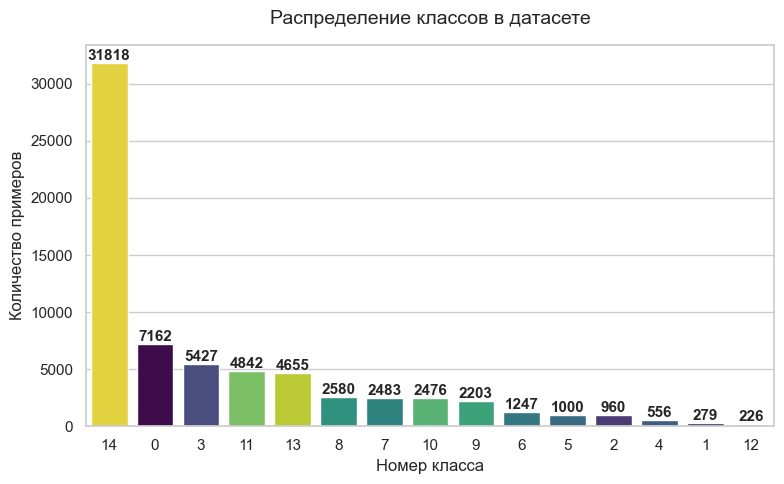

In [33]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="class_id",
    hue='class_id',
    order=df["class_id"].value_counts().index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, weight="bold")

plt.title("Распределение классов в датасете", fontsize=14, pad=15)
plt.xlabel("Номер класса", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)

plt.tight_layout()
plt.show()

# Создание сбалансированных train/val датасетов

Для каждого изображения соберем классы, что на нём есть

In [34]:
image_classes = df.groupby('image_id')['class_id'].apply(list).reset_index()
image_classes

,image_id,class_id
0,000434271f63a053c4128a0ba6352c7f,"[14, 14, 14]"
1,00053190460d56c53cc3e57321387478,"[14, 14, 14]"
2,0005e8e3701dfb1dd93d53e2ff537b6e,"[7, 8, 6, 7, 4]"
3,0006e0a85696f6bb578e84fafa9a5607,"[14, 14, 14]"
4,0007d316f756b3fa0baea2ff514ce945,"[13, 11, 3, 11, 13, 0, 5, 5, 0, 11, 13]"
...,...,...
14995,ffe6f9fe648a7ec29a50feb92d6c15a4,"[3, 0, 9, 3, 3]"
14996,ffea246f04196af602c7dc123e5e48fc,"[14, 14, 14]"
14997,ffeffc54594debf3716d6fcd2402a99f,"[0, 0, 0]"
14998,fff0f82159f9083f3dd1f8967fc54f6a,"[14, 14, 14]"


Уникальные классы

In [35]:
unique_classes = sorted(df['class_id'].unique())
unique_classes

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14)]

Заполним матрицу признаков: 1 если класс есть на фото, 0 если нет

In [36]:
for cls in unique_classes:
    image_classes[f'class_{cls}'] = image_classes['class_id'].apply(lambda x: 1 if cls in x else 0)

image_classes

,image_id,class_id,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9,class_10,class_11,class_12,class_13,class_14
0,000434271f63a053c4128a0ba6352c7f,"[14, 14, 14]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,00053190460d56c53cc3e57321387478,"[14, 14, 14]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0005e8e3701dfb1dd93d53e2ff537b6e,"[7, 8, 6, 7, 4]",0,0,0,0,1,0,1,1,1,0,0,0,0,0,0
3,0006e0a85696f6bb578e84fafa9a5607,"[14, 14, 14]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0007d316f756b3fa0baea2ff514ce945,"[13, 11, 3, 11, 13, 0, 5, 5, 0, 11, 13]",1,0,0,1,0,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,ffe6f9fe648a7ec29a50feb92d6c15a4,"[3, 0, 9, 3, 3]",1,0,0,1,0,0,0,0,0,1,0,0,0,0,0
14996,ffea246f04196af602c7dc123e5e48fc,"[14, 14, 14]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
14997,ffeffc54594debf3716d6fcd2402a99f,"[0, 0, 0]",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14998,fff0f82159f9083f3dd1f8967fc54f6a,"[14, 14, 14]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [37]:
X = image_classes['image_id'].values
y = image_classes[[f'class_{cls}' for cls in unique_classes]].values

Настроим стратифицированное разделение на 5 фолдов

In [38]:
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in mskf.split(X, y):
    train_images = X[train_idx]
    val_images = X[val_idx]
    break

print(f"Изображений для обучения: {len(train_images)}")
print(f"Изображений для валидации: {len(val_images)}")

Изображений для обучения: 12000
Изображений для валидации: 3000


In [39]:
train_df = df[df['image_id'].isin(train_images)].reset_index(drop=True)
val_df = df[df['image_id'].isin(val_images)].reset_index(drop=True)

train_df.to_csv(TRAIN_PROCESSED_SPLIT_CSV_PATH, index=False)
val_df.to_csv(VAL_SPLIT_CSV_PATH, index=False)

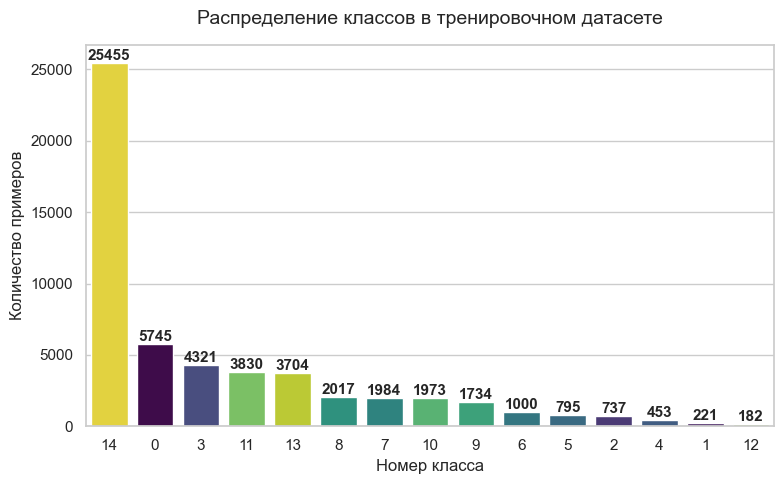

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x="class_id",
    hue='class_id',
    order=train_df["class_id"].value_counts().index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, weight="bold")

plt.title("Распределение классов в тренировочном датасете", fontsize=14, pad=15)
plt.xlabel("Номер класса", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)

plt.tight_layout()
plt.show()

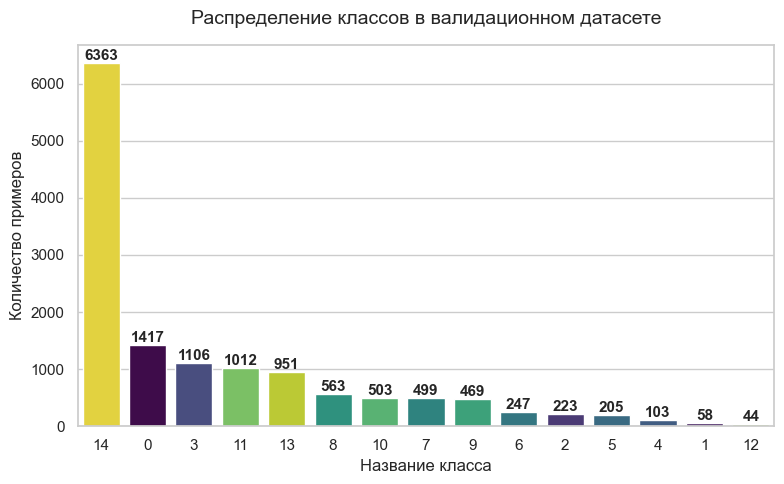

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=val_df,
    x="class_id",
    hue='class_id',
    order=val_df["class_id"].value_counts().index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, weight="bold")

plt.title("Распределение классов в валидационном датасете", fontsize=14, pad=15)
plt.xlabel("Название класса", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)

plt.tight_layout()
plt.show()

# Написание PyTorch Dataset

In [42]:
class VinBigDataDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.df = dataframe
        self.image_ids = self.df['image_id'].unique()
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        img_id = self.image_ids[index]
        img_path = self.image_dir / f'{img_id}.png'

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # uint8

        records = self.df[(self.df['image_id'] == img_id) & (self.df['class_id'] != 14)]

        if len(records) == 0:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros(0, dtype=torch.long)
            if self.transforms:
                image = self.transforms(image=image)['image']
        else:
            boxes = records[['x_min', 'y_min', 'x_max', 'y_max']].values
            labels = records['class_id'].values + 1  # сдвиг: фон = 0

            if self.transforms:
                sample = self.transforms(image=image, bboxes=boxes, class_labels=labels)
                image = sample['image']
                boxes = list(sample['bboxes'])
                labels = list(sample['class_labels'])

            boxes_tensor = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
            labels_tensor = torch.tensor(labels, dtype=torch.long)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor
        }

        return image, target
    
    def get_image_name_by_index(self, index):
        return self.image_ids[index]
    
    def get_image_index_by_name(self, name):
        for ind, img_name in enumerate(self.image_ids):
            if img_name == name:
                return ind
        return -1

Протестируем

In [43]:
def show_image(dataset, ind):
    image, target = dataset[ind]

    boxes = target['boxes'].numpy()
    labels = target['labels'].numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image, cmap='gray' if image.shape[2] == 1 else None)

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        
        width = xmax - xmin
        height = ymax - ymin
        
        if label == 14:
            continue
            
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        ax.text(
            xmin, ymin - 10, f"Class: {label}", 
            color='white', bbox=dict(facecolor='red', alpha=0.5)
        )
        ax.set_title(f"Индекс: {ind} | Обнаружено патологий: {len(boxes)}", fontsize=14)
        
    plt.axis('off')
    plt.show()

Всего уникальных снимков в тестовом датасете: 12000
Изображение 9ef084b09e407e4f8f00932602d1a88d.png


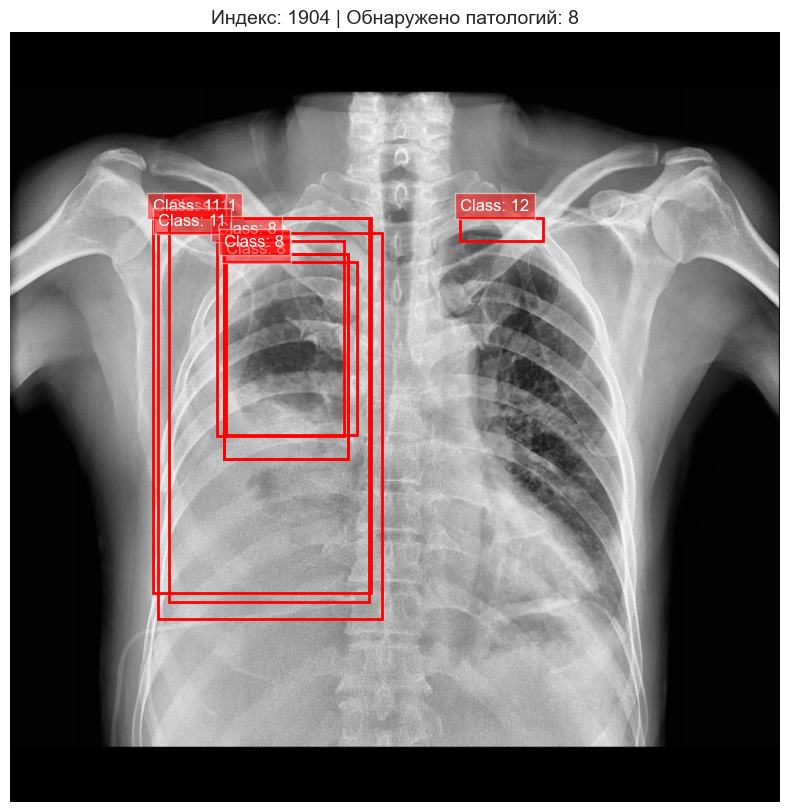

In [46]:
df = pd.read_csv(TRAIN_PROCESSED_SPLIT_CSV_PATH)
dataset = VinBigDataDataset(dataframe=df, image_dir=IMAGE_DIR, transforms=None)
print(f"Всего уникальных снимков в тестовом датасете: {len(dataset)}")

ind = 1904 #np.random.randint(0, 5000)
print(f'Изображение {dataset.get_image_name_by_index(ind)}.png')
show_image(dataset, ind)


Необходимо отфильтровать боксы. Вместо нескольких боксов одного класса создать один большой. Необходимо применить алгоритм WBF, чтобы слить все схожие боксы в один усреднённый


In [48]:
IMAGE_SIZE = 1024
IOU_THR = 0.45 # порог слияния боксов
MIN_RADS = 1  # минимум радиологов для сохранения бокса
N_RADS = 3 # количество радиологов, разметивших изображение
MIN_SCORE = MIN_RADS / N_RADS

df = pd.read_csv(TRAIN_PROCESSED_SPLIT_CSV_PATH)

# Нормализация координат
coord_cols = ['x_min', 'y_min', 'x_max', 'y_max']
df[coord_cols] = df[coord_cols].clip(0, IMAGE_SIZE) / IMAGE_SIZE


def wbf_for_image(group: pd.DataFrame) -> list[dict]:
    if group['class_id'].nunique() == 1 and group['class_id'].iloc[0] == 14:
        return [group.iloc[0].to_dict()]

    result = []
    total_rads_on_image = group['rad_id'].nunique()
    all_rads = group['rad_id'].unique()

    pathology_group = group[group['class_id'] != 14]
    if pathology_group.empty:
        return [group[group['class_id'] == 14].iloc[0].to_dict()]

    for cls_id, cls_group in pathology_group.groupby('class_id'):
        boxes_list, scores_list, labels_list = [], [], []

        for rad_id in all_rads:
            rad_boxes = cls_group.loc[
                cls_group['rad_id'] == rad_id, coord_cols
            ].values.tolist()
            boxes_list.append(rad_boxes)
            scores_list.append([1.0] * len(rad_boxes))
            labels_list.append([cls_id] * len(rad_boxes))

        merged_boxes, merged_scores, merged_labels = weighted_boxes_fusion(
            boxes_list,
            scores_list,
            labels_list,
            weights=None,
            iou_thr=IOU_THR,
            skip_box_thr=0.0,
        )

        for box, score, label in zip(merged_boxes, merged_scores, merged_labels):
            actual_rads_count = round(score * total_rads_on_image)

            if actual_rads_count < 1:
                continue

            x_min, y_min, x_max, y_max = (np.array(box) * IMAGE_SIZE).tolist()
            result.append({
                'image_id': group['image_id'].iloc[0],
                'class_name': cls_group['class_name'].iloc[0],
                'class_id': int(label),
                'rad_id': 'wbf_merged',
                'x_min': x_min,
                'y_min': y_min,
                'x_max': x_max,
                'y_max': y_max,
                'wbf_score': round(score, 4),
            })

    if not result:
        return [{
            'image_id': group['image_id'].iloc[0], 'class_name': 'No finding',
            'class_id': 14, 'rad_id': 'wbf_merged',
            'x_min': 0, 'y_min': 0, 'x_max': 1, 'y_max': 1, 'wbf_score': 1.0
        }]

    return result


result_rows = []
grouped = df.groupby('image_id')
print(f"WBF для {len(grouped)} снимков, порог консенсуса: {MIN_RADS}/{N_RADS} радиологов...")

for image_id, group in tqdm(grouped):
    result_rows.extend(wbf_for_image(group))

wbf_df = pd.DataFrame(result_rows)

print()
print(f"До WBF:  {len(df[df['class_id'] != 14])} боксов с патологиями")
print(f"После WBF: {len(wbf_df[wbf_df['class_id'] != 14])} боксов с патологиями")
print()

wbf_df.to_csv(TRAIN_PROCESSED_WBF_PATH, index=False)

WBF для 12000 снимков, порог консенсуса: 1/3 радиологов...


100%|██████████| 12000/12000 [00:34<00:00, 346.21it/s]



До WBF:  28696 боксов с патологиями
После WBF: 18462 боксов с патологиями



Проверим на 1904 снимке

Всего уникальных снимков в тестовом датасете: 12000


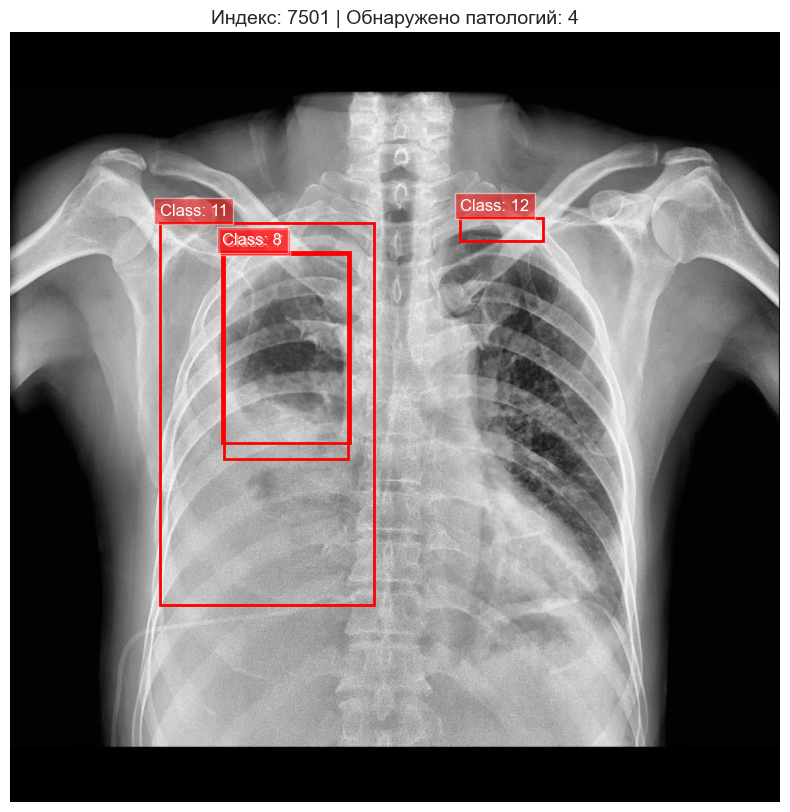

In [50]:
df = pd.read_csv(TRAIN_PROCESSED_WBF_PATH)
dataset = VinBigDataDataset(dataframe=df, image_dir=IMAGE_DIR, transforms=None)
print(f"Всего уникальных снимков в тестовом датасете: {len(dataset)}")

show_image(dataset, dataset.get_image_index_by_name('9ef084b09e407e4f8f00932602d1a88d'))

Распределение классов в получившемся датасете

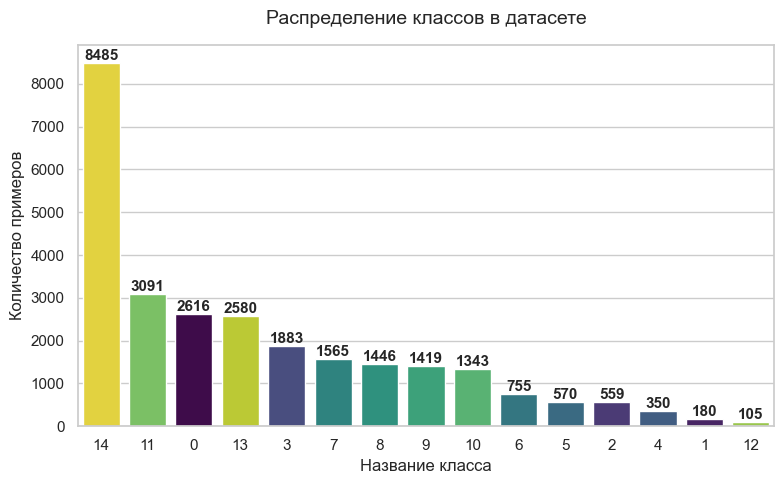

In [51]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

wbf_df = pd.read_csv(TRAIN_PROCESSED_WBF_PATH)
ax = sns.countplot(
    data=wbf_df,
    x="class_id",
    hue='class_id',
    order=wbf_df["class_id"].value_counts().index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, weight="bold")

plt.title("Распределение классов в датасете", fontsize=14, pad=15)
plt.xlabel("Название класса", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)

plt.tight_layout()
plt.show()

Сбалансируем, удалив объекты 14 класса

In [52]:
df = pd.read_csv(TRAIN_PROCESSED_WBF_PATH)

images_with_pathologies = df[df["class_id"] != 14]["image_id"].unique()

df_pathologies = df[df["image_id"].isin(images_with_pathologies)]

df_normal_all = df[~df["image_id"].isin(images_with_pathologies)]

unique_normal_ids = df_normal_all["image_id"].unique()

unique_normal_ids = pd.Series(unique_normal_ids)

sampled_normal_ids = unique_normal_ids.sample(n=2600, random_state=42)

df_normal_sampled = df_normal_all[df_normal_all["image_id"].isin(sampled_normal_ids)]

df_final = pd.concat([df_pathologies, df_normal_sampled], axis=0)

df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

df_final.to_csv(TRAIN_BALANCED_CSV_PATH, index=False)

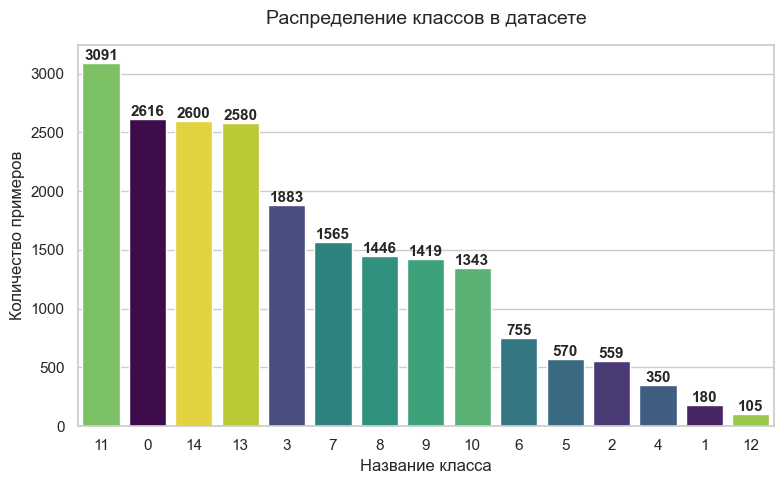

In [53]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

df_dinal = pd.read_csv(TRAIN_BALANCED_CSV_PATH)
ax = sns.countplot(
    data=df_final,
    x="class_id",
    hue='class_id',
    order=df_final["class_id"].value_counts().index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, weight="bold")

plt.title("Распределение классов в датасете", fontsize=14, pad=15)
plt.xlabel("Название класса", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)

plt.tight_layout()
plt.show()